**Формирование временных окон и сравнение архитектур автоэнкодеров: LSTM vs GRU vs TCN**

**Цель**: Эмпирический выбор оптимальной архитектуры для сжатия временных окон скважин.

**Этапы**:
1. Формирование скользящих окон (ЭЦН: 60×9, ШГН: 120×9)
2. Подбор оптимальной размерности латентного пространства (4–7 измерений)
3. Обучение и валидация автоэнкодеров
4. Визуализация качества реконструкции

**Вход**: ../data/processed/{ecn,shgn}_{train,val,test}.csv + scaler_*.pkl  
**Выход**: models/{ecn,shgn}/model.pth + scaler.pkl

In [23]:
import pickle
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

# ==== КОНФИГУРАЦИЯ И ЦВЕТОВАЯ СХЕМА ====

In [45]:
COLORS = {
    "primary": "#2E86AB",
    "secondary": "#A23B72",
    "accent": "#F18F01",
    "success": "#C73E1D",
    "neutral": "#6B7280",
}

ARCH_COLORS = {"LSTM": COLORS["primary"], "GRU": COLORS["secondary"], "TCN": COLORS["accent"]}

plt.rcParams.update(
    {
        "figure.figsize": (15, 6),
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.dpi": 100,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
    }
)

DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("models")
FEATURE_COLUMNS = [
    "us_center",
    "us_periph",
    "gas_center",
    "gas_periph",
    "temp",
    "water_center",
    "water_periph",
    "gas_integral",
    "water_integral",
]

WINDOW_SIZES = {"ecn": 60, "shgn": 120}
LATENT_DIMS = [4, 5, 6, 7]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")

Устройство: cuda


# ==== 1. ЗАГРУЗКА ДАННЫХ И ФОРМИРОВАНИЕ ОКОН ====

In [77]:
def load_and_create_windows(prefix: str, window_size: int) -> tuple:
    train = pd.read_csv(DATA_DIR / f"{prefix}_train.csv", parse_dates=["timestamp"])
    val = pd.read_csv(DATA_DIR / f"{prefix}_val.csv", parse_dates=["timestamp"])
    test = pd.read_csv(DATA_DIR / f"{prefix}_test.csv", parse_dates=["timestamp"])

    with open(DATA_DIR / f"scaler_{prefix}.pkl", "rb") as f:
        scaler = pickle.load(f)

    def create_windows(df):
        X = df[FEATURE_COLUMNS].values
        well_ids = df["well"].values if "well" in df.columns else None
        windows = []
        for i in range(0, len(X) - window_size + 1):
            if well_ids is not None and len(set(well_ids[i : i + window_size])) > 1:
                continue
            windows.append(X[i : i + window_size])
        return np.array(windows, dtype=np.float32)

    X_train = create_windows(train)
    X_val = create_windows(val)
    X_test = create_windows(test)

    print(f"{prefix.upper()}: окна — train={X_train.shape}, val={X_val.shape}, test={X_test.shape}")
    return X_train, X_val, X_test, scaler

In [78]:
X_ecn_train, X_ecn_val, X_ecn_test, scaler_ecn = load_and_create_windows("ecn", WINDOW_SIZES["ecn"])
X_shgn_train, X_shgn_val, X_shgn_test, scaler_shgn = load_and_create_windows("shgn", WINDOW_SIZES["shgn"])

ECN: окна — train=(35503, 60, 9), val=(7562, 60, 9), test=(7562, 60, 9)
SHGN: окна — train=(72382, 120, 9), val=(14993, 120, 9), test=(5229, 120, 9)


In [79]:
def plot_random_window(X: np.ndarray, window_size: int, pump_type: str, color: str) -> None:
    idx = np.random.randint(0, len(X))
    window = X[idx]

    fig, axes = plt.subplots(3, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, feature in enumerate(FEATURE_COLUMNS):
        axes[i].plot(window[:, i], color=color, linewidth=2.5, alpha=0.9)
        axes[i].set_title(feature, fontsize=11, fontweight="bold", color=color)
        axes[i].set_xlabel("Время (×10 сек)", fontsize=9)
        axes[i].grid(True, alpha=0.4, linestyle="-", linewidth=0.7)

    duration_min = window_size * 10 / 60
    fig.suptitle(
        f"{pump_type}: случайное окно #{idx} ({window_size} точек = {duration_min:.1f} мин)",
        fontsize=15,
        fontweight="bold",
        y=0.995,
        color=color,
    )
    plt.tight_layout()
    plt.show()

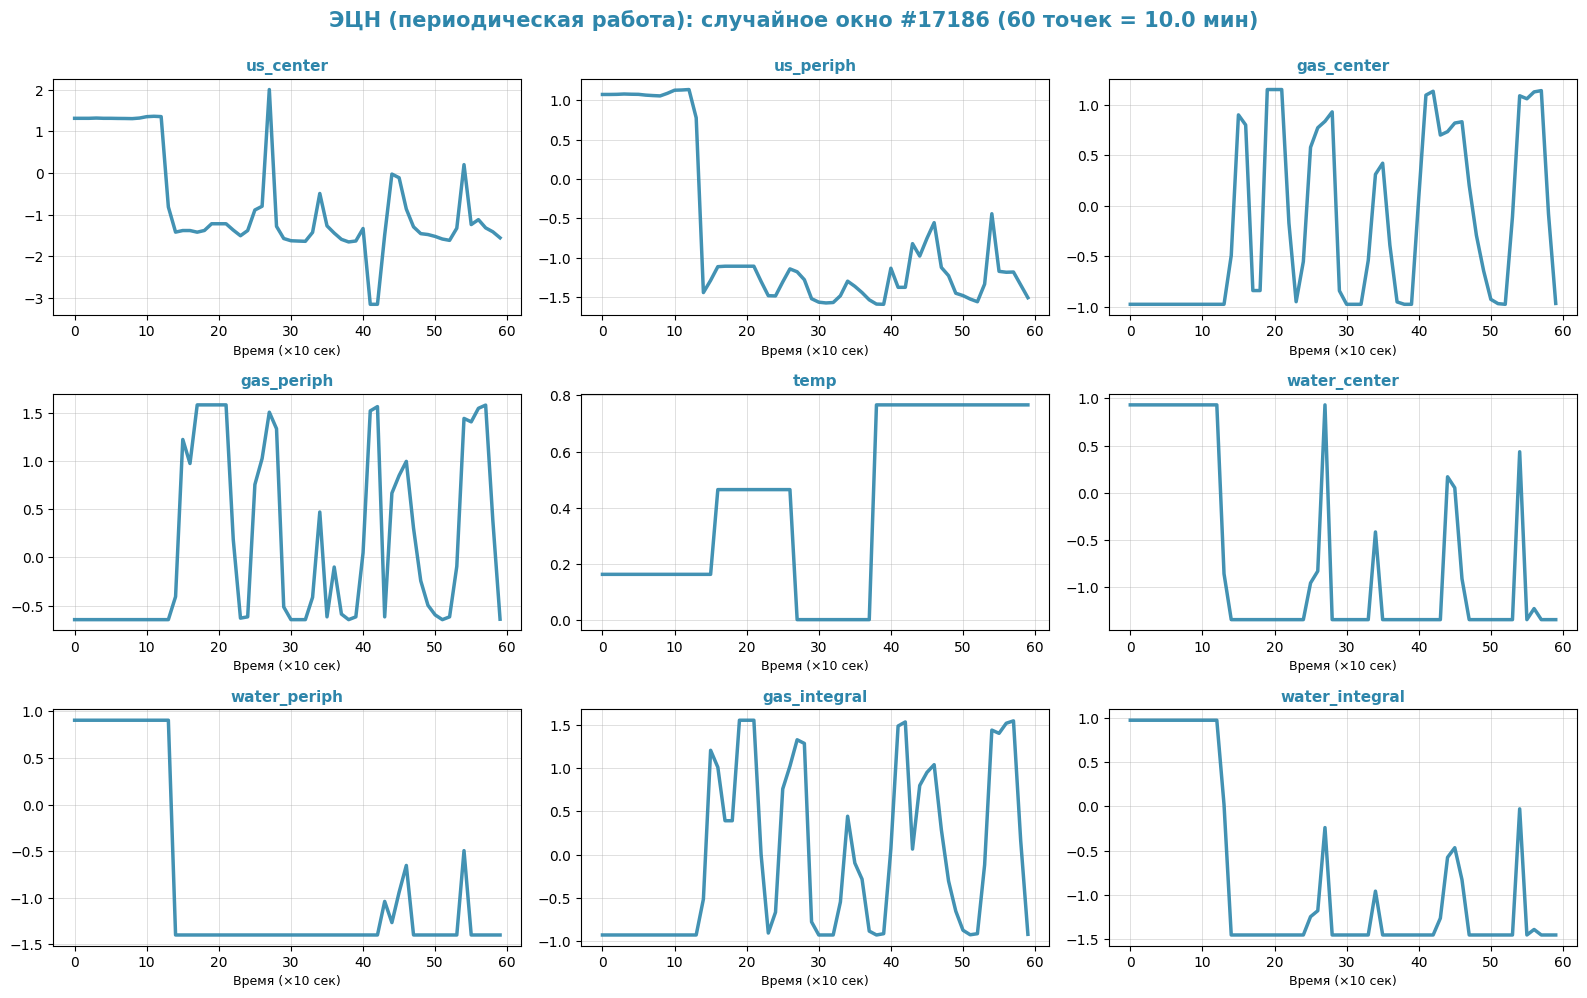

In [80]:
plot_random_window(X_ecn_train, WINDOW_SIZES["ecn"], "ЭЦН (периодическая работа)", COLORS["primary"])

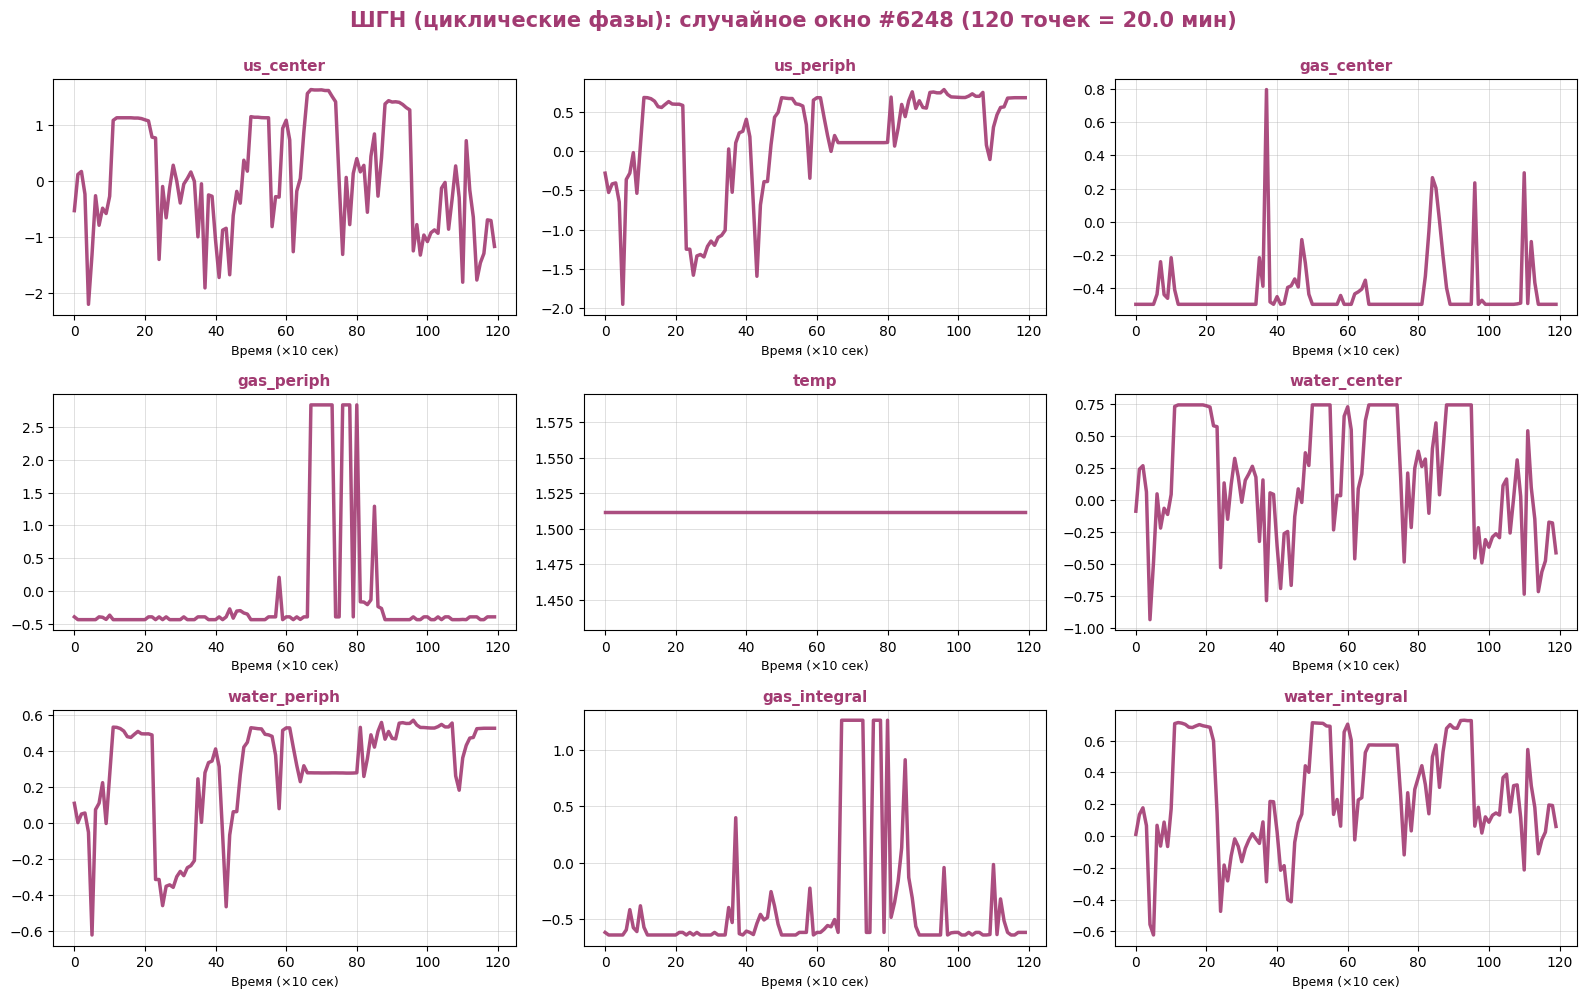

In [83]:
plot_random_window(X_shgn_train, WINDOW_SIZES["shgn"], "ШГН (циклические фазы)", COLORS["secondary"])

# ==== 2. АРХИТЕКТУРЫ АВТОЭНКОДЕРОВ ====

In [117]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=9, hidden_size=128, latent_dim=6, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_size = hidden_size
        self.latent_dim = latent_dim
        self.num_layers = num_layers
        self.seq_len = None

        self.encoder_lstm = nn.LSTM(
            input_dim, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0
        )
        self.encoder_fc = nn.Linear(hidden_size * num_layers, latent_dim)

        self.decoder_fc_h = nn.Linear(latent_dim, hidden_size * num_layers)
        self.decoder_fc_c = nn.Linear(latent_dim, hidden_size * num_layers)
        self.decoder_fc_input = nn.Linear(latent_dim, hidden_size)

        self.decoder_lstm = nn.LSTM(
            hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0
        )
        self.output_layer = nn.Linear(hidden_size, input_dim)

        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param)
            elif "weight_hh" in name:
                nn.init.orthogonal_(param)
            elif "bias" in name:
                nn.init.zeros_(param)

    def encode(self, x):
        batch_size = x.size(0)
        _, (h_n, _) = self.encoder_lstm(x)
        h_flat = h_n.permute(1, 0, 2).reshape(batch_size, -1).contiguous()
        z = self.encoder_fc(h_flat)
        return z

    def decode(self, z, seq_len):
        batch_size = z.size(0)

        h0 = self.decoder_fc_h(z).view(batch_size, self.num_layers, self.hidden_size)
        h0 = h0.permute(1, 0, 2).contiguous()
        c0 = self.decoder_fc_c(z).view(batch_size, self.num_layers, self.hidden_size)
        c0 = c0.permute(1, 0, 2).contiguous()

        input_seq = self.decoder_fc_input(z).unsqueeze(1).repeat(1, seq_len, 1)

        out, _ = self.decoder_lstm(input_seq, (h0, c0))
        recon = self.output_layer(out)
        return recon

    def forward(self, x):
        self.seq_len = x.size(1)
        z = self.encode(x)
        recon = self.decode(z, x.size(1))
        return recon, z

In [116]:
class GRUAutoencoder(nn.Module):
    def __init__(self, input_dim=9, hidden_size=128, latent_dim=6, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_size = hidden_size
        self.latent_dim = latent_dim
        self.num_layers = num_layers

        self.encoder_gru = nn.GRU(
            input_dim, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0
        )
        self.encoder_fc = nn.Linear(hidden_size * num_layers, latent_dim)

        self.decoder_fc_h = nn.Linear(latent_dim, hidden_size * num_layers)
        self.decoder_fc_input = nn.Linear(latent_dim, hidden_size)

        self.decoder_gru = nn.GRU(
            hidden_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0
        )
        self.output_layer = nn.Linear(hidden_size, input_dim)

        self._init_weights()

    def _init_weights(self):
        for name, param in self.named_parameters():
            if "weight_ih" in name:
                nn.init.xavier_uniform_(param)
            elif "weight_hh" in name:
                nn.init.orthogonal_(param)
            elif "bias" in name:
                nn.init.zeros_(param)

    def encode(self, x):
        batch_size = x.size(0)
        _, h_n = self.encoder_gru(x)
        h_flat = h_n.permute(1, 0, 2).reshape(batch_size, -1).contiguous()
        z = self.encoder_fc(h_flat)
        return z

    def decode(self, z, seq_len):
        batch_size = z.size(0)

        h0 = self.decoder_fc_h(z).view(batch_size, self.num_layers, self.hidden_size)
        h0 = h0.permute(1, 0, 2).contiguous()

        input_seq = self.decoder_fc_input(z).unsqueeze(1).repeat(1, seq_len, 1)

        out, _ = self.decoder_gru(input_seq, h0)
        recon = self.output_layer(out)
        return recon

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z, x.size(1))
        return recon, z

In [86]:
class CausalConv1d(nn.Conv1d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, dilation=1, groups=1, bias=True):
        super().__init__(
            in_channels,
            out_channels,
            kernel_size,
            stride=stride,
            padding=0,
            dilation=dilation,
            groups=groups,
            bias=bias,
        )
        self.kernel_size = (kernel_size,)
        self.dilation = (dilation,)

    def forward(self, x):
        pad = (self.kernel_size[0] - 1) * self.dilation[0]
        return F.conv1d(
            F.pad(x, (pad, 0)),
            self.weight,
            self.bias,
            self.stride,
            padding=0,
            dilation=self.dilation,
            groups=self.groups,
        )


class TemporalBlock(nn.Module):
    def __init__(self, n_in, n_out, kernel_size, dilation, dropout=0.2):
        super().__init__()
        self.conv1 = CausalConv1d(n_in, n_out, kernel_size, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(n_out)
        self.act1 = nn.PReLU(n_out)
        self.drop1 = nn.Dropout(dropout)
        self.conv2 = CausalConv1d(n_out, n_out, kernel_size, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(n_out)
        self.drop2 = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(n_in, n_out, 1) if n_in != n_out else None
        self.final_act = nn.PReLU(n_out)
        self._init_weights()

    def _init_weights(self):
        nn.init.kaiming_normal_(self.conv1.weight, mode="fan_in", nonlinearity="leaky_relu", a=0.25)
        nn.init.kaiming_normal_(self.conv2.weight, mode="fan_in", nonlinearity="leaky_relu", a=0.25)
        if self.downsample is not None:
            nn.init.kaiming_normal_(self.downsample.weight, mode="fan_in", nonlinearity="leaky_relu", a=0.25)

    def forward(self, x):
        res = x if self.downsample is None else self.downsample(x)
        out = self.drop1(self.act1(self.bn1(self.conv1(x))))
        out = self.drop2(self.bn2(self.conv2(out)))
        return self.final_act(out + res)

In [ ]:
class TCNAutoencoder(nn.Module):
    def __init__(
        self, input_dim=9, hidden_size=128, latent_dim=6, num_layers=3, kernel_size=3, dilation_base=2, dropout=0.2
    ):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_size = hidden_size
        self.latent_dim = latent_dim
        self.num_layers = num_layers

        enc_layers = []
        for i in range(num_layers):
            n_in = input_dim if i == 0 else hidden_size
            dilation = dilation_base**i
            enc_layers.append(TemporalBlock(n_in, hidden_size, kernel_size, dilation, dropout))
        self.encoder = nn.Sequential(*enc_layers)

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.fc_enc = nn.Linear(hidden_size, latent_dim)

        self.fc_dec_start = nn.Linear(latent_dim, hidden_size)
        self.fc_dec_end = nn.Linear(latent_dim, hidden_size)

        dec_layers = []
        for i in range(num_layers):
            dilation = dilation_base ** (num_layers - 1 - i)
            dec_layers.append(TemporalBlock(hidden_size, hidden_size, kernel_size, dilation, dropout))
        self.decoder = nn.Sequential(*dec_layers)

        self.recon_layer = nn.Conv1d(hidden_size, input_dim, 1)
        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.fc_enc.weight)
        nn.init.zeros_(self.fc_enc.bias)
        nn.init.xavier_uniform_(self.fc_dec_start.weight)
        nn.init.zeros_(self.fc_dec_start.bias)
        nn.init.xavier_uniform_(self.fc_dec_end.weight)
        nn.init.zeros_(self.fc_dec_end.bias)

    def encode(self, x):
        x = x.transpose(1, 2)
        feat = self.encoder(x)
        pooled = self.global_pool(feat).squeeze(-1)
        z = self.fc_enc(pooled)
        return z

    def decode(self, z, seq_len):
        batch_size = z.size(0)

        h_start = self.fc_dec_start(z).view(batch_size, self.hidden_size, 1)
        h_end = self.fc_dec_end(z).view(batch_size, self.hidden_size, 1)

        positions = torch.linspace(0, 1, seq_len, device=z.device).view(1, 1, seq_len)
        h_dynamic = h_start + (h_end - h_start) * positions

        dec_feat = self.decoder(h_dynamic)
        recon = self.recon_layer(dec_feat)
        return recon.transpose(1, 2)

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z, x.size(1))
        return recon, z

#  ==== 3. ОБУЧЕНИЕ И ВАЛИДАЦИЯ ====

In [119]:
def create_dataloaders(X_train, X_val, X_test, batch_size=256):
    loaders = {}
    for name, X in [("train", X_train), ("val", X_val), ("test", X_test)]:
        tensor = torch.from_numpy(X).float()
        ds = TensorDataset(tensor, tensor)
        loaders[name] = DataLoader(ds, batch_size=batch_size, shuffle=(name == "train"), drop_last=False)
    return loaders["train"], loaders["val"], loaders["test"]

In [120]:
def train_model(model, train_loader, val_loader, test_loader, epochs=100, lr=5e-4, weight_decay=1e-5, device=DEVICE):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay, betas=(0.9, 0.95))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-7)
    best_val_loss, best_state, patience = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for _ in tqdm(range(epochs), desc="Эпоха", leave=False):
        model.train()
        total_loss, samples = 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            recon, z = model(x)
            loss = F.mse_loss(recon, y) + 0.001 * torch.mean(z**2)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            samples += x.size(0)
        train_loss = total_loss / samples

        model.eval()
        total_loss, total_mae, total_var, samples = 0, 0, 0, 0
        with torch.no_grad():
            for x, _ in val_loader:
                x = x.to(device)
                recon, z = model(x)
                loss = F.mse_loss(recon, x) + 0.001 * torch.mean(z**2)
                mae = F.l1_loss(recon, x)
                total_loss += loss.item() * x.size(0)
                total_mae += mae.item() * x.size(0)
                total_var += x.var(dim=(0, 1)).sum().item() * x.size(0)
                samples += x.size(0)
        val_loss = total_loss / samples
        val_mae = total_mae / samples
        val_r2 = 1 - val_loss / (total_var / samples + 1e-8)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_mae = val_mae
            best_val_r2 = val_r2
            best_state = model.state_dict().copy()
            patience = 0
        else:
            patience += 1
            if patience >= 15:
                break

    model.load_state_dict(best_state)

    model.eval()
    total_loss, total_mae, total_var, samples = 0, 0, 0, 0
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            recon, z = model(x)
            loss = F.mse_loss(recon, x)
            mae = F.l1_loss(recon, x)
            total_loss += loss.item() * x.size(0)
            total_mae += mae.item() * x.size(0)
            total_var += x.var(dim=(0, 1)).sum().item() * x.size(0)
            samples += x.size(0)
    test_loss = total_loss / samples
    test_mae = total_mae / samples
    test_r2 = 1 - test_loss / (total_var / samples + 1e-8)

    return best_val_loss, best_val_mae, best_val_r2, test_loss, test_mae, test_r2, history

In [121]:
def evaluate_architectures(X_train, X_val, X_test, pump_type, device=DEVICE):
    architectures = {
        "LSTM": LSTMAutoencoder,
        "GRU": GRUAutoencoder,
        "TCN": TCNAutoencoder,
    }

    results = {}
    train_loader, val_loader, test_loader = create_dataloaders(
        X_train, X_val, X_test, batch_size=256
    )

    print(f"\n{'=' * 70}")
    print(f"Сравнение архитектур для {pump_type}")
    print(f"{'=' * 70}")

    for name, ModelClass in architectures.items():
        print(f"\n{name}: подбор размерности латентного пространства")
        arch_results = []

        for latent_dim in LATENT_DIMS:
            model = ModelClass(
                input_dim=len(FEATURE_COLUMNS),
                hidden_size=256,
                latent_dim=latent_dim,
                num_layers=2,
                dropout=0.1,
            ).to(device)

            val_loss, val_mae, val_r2, test_loss, test_mae, test_r2, _ = train_model(
                model, train_loader, val_loader, test_loader, epochs=100, device=device
            )
            arch_results.append(
                {
                    "latent_dim": latent_dim,
                    "val_loss": val_loss,
                    "val_mae": val_mae,
                    "val_r2": val_r2,
                    "test_loss": test_loss,
                    "test_mae": test_mae,
                    "test_r2": test_r2,
                    "model": model,
                }
            )
            print(
                f"  latent_dim={latent_dim:2d} → val_loss={val_loss:.6f} | val_MAE={val_mae:.4f} | val_R²={val_r2:.4f}"
            )

        best = min(arch_results, key=lambda x: x["val_loss"])
        results[name] = {
            "best": best,
            "all": arch_results,
            "color": ARCH_COLORS[name],
        }
        print(f"  → ЛУЧШАЯ: latent_dim={best['latent_dim']} (val_loss={best['val_loss']:.6f}, R²={best['val_r2']:.4f})")

    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    for name, res in results.items():
        dims = [r["latent_dim"] for r in res["all"]]
        losses = [r["val_loss"] for r in res["all"]]
        ax1.plot(dims, losses, marker="o", linewidth=2.5, markersize=9, label=name, color=res["color"])

    best_arch = min(results, key=lambda x: results[x]["best"]["val_loss"])
    best_dim = results[best_arch]["best"]["latent_dim"]
    best_loss = results[best_arch]["best"]["val_loss"]
    ax1.axvline(
        best_dim,
        color=COLORS["success"],
        linestyle="--",
        linewidth=2.5,
        label=f"Оптимум: {best_arch} ({best_dim}D, MSE={best_loss:.5f})",
    )

    ax1.set_xlabel("Размерность латентного пространства", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Validation MSE", fontsize=12, fontweight="bold")
    ax1.set_title(f"{pump_type}: сравнение архитектур", fontsize=14, fontweight="bold")
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.4)

    table_data = []
    for name in ["LSTM", "GRU", "TCN"]:
        best = results[name]["best"]
        marker = "★" if name == best_arch else ""
        table_data.append(
            [
                f"{name} {marker}",
                f"{best['latent_dim']}",
                f"{best['val_loss']:.5f}",
                f"{best['val_r2']:.3f}",
                f"{best['test_loss']:.5f}",
            ]
        )

    table = ax2.table(
        cellText=table_data,
        colLabels=["Архитектура", "Latent dim", "Val MSE", "Val R²", "Test MSE"],
        cellLoc="center",
        loc="center",
        fontsize=12,
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2.2)

    for i, name in enumerate(["LSTM", "GRU", "TCN"]):
        if name == best_arch:
            for j in range(5):
                table[(i + 1, j)].set_facecolor("#90EE90")

    ax2.axis("off")
    ax2.set_title(f"{pump_type}: рейтинг архитектур", fontsize=14, fontweight="bold", pad=20)

    plt.tight_layout()
    plt.show()

    return results, best_arch, results[best_arch]["best"]["model"]

# ==== 4. СРАВНЕНИЕ ДЛЯ ЭЦН ====

In [122]:
ecn_results, ecn_best_arch, ecn_best_model = evaluate_architectures(
    X_ecn_train, X_ecn_val, X_ecn_test, "ЭЦН"
)


Сравнение архитектур для ЭЦН

LSTM: подбор размерности латентного пространства


KeyboardInterrupt: 

# ==== 5. СРАВНЕНИЕ ДЛЯ ШГН ====

In [ ]:
shgn_results, shgn_best_arch, shgn_best_model = evaluate_architectures(
    X_shgn_train, X_shgn_val, X_shgn_test, "ШГН"
)

# ==== 6. ВИЗУАЛИЗАЦИЯ РЕКОНСТРУКЦИИ ====

In [114]:
def plot_reconstruction(model, X_val, seq_len, pump_type, color, n_samples=3):
    model.eval()
    indices = np.random.choice(len(X_val), n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, len(FEATURE_COLUMNS), figsize=(20, 3 * n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, -1)

    with torch.no_grad():
        for row_idx, idx in enumerate(indices):
            x = torch.FloatTensor(X_val[idx : idx + 1]).to(DEVICE)
            recon, _ = model(x)
            x_np = x[0].cpu().numpy()
            recon_np = recon[0].cpu().numpy()

            for col_idx, feature in enumerate(FEATURE_COLUMNS):
                ax = axes[row_idx, col_idx]
                ax.plot(x_np[:, col_idx], color=color, linewidth=2.5, alpha=0.9, label="Оригинал")
                ax.plot(
                    recon_np[:, col_idx],
                    color=COLORS["success"],
                    linewidth=2.0,
                    linestyle="--",
                    alpha=0.85,
                    label="Реконструкция",
                )
                ax.set_title(f"{feature}" if row_idx == 0 else "", fontsize=10, fontweight="bold")
                ax.grid(True, alpha=0.3)
                if col_idx == 0:
                    ax.set_ylabel(f"Окно #{idx}", fontsize=10)
                if row_idx == n_samples - 1:
                    ax.set_xlabel("Время (×10 сек)", fontsize=9)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=11, frameon=True, bbox_to_anchor=(0.5, -0.02))

    duration_min = seq_len * 10 / 60
    fig.suptitle(
        f"{pump_type} (окно {seq_len} точек = {duration_min:.1f} мин): "
        f"качество реконструкции ({model.__class__.__name__.replace('Autoencoder', '')})",
        fontsize=15,
        fontweight="bold",
        y=0.98,
    )

    plt.tight_layout(rect=(0.0, 0.05, 1.0, 0.95))
    plt.show()


Визуализация реконструкции для ЭЦН:


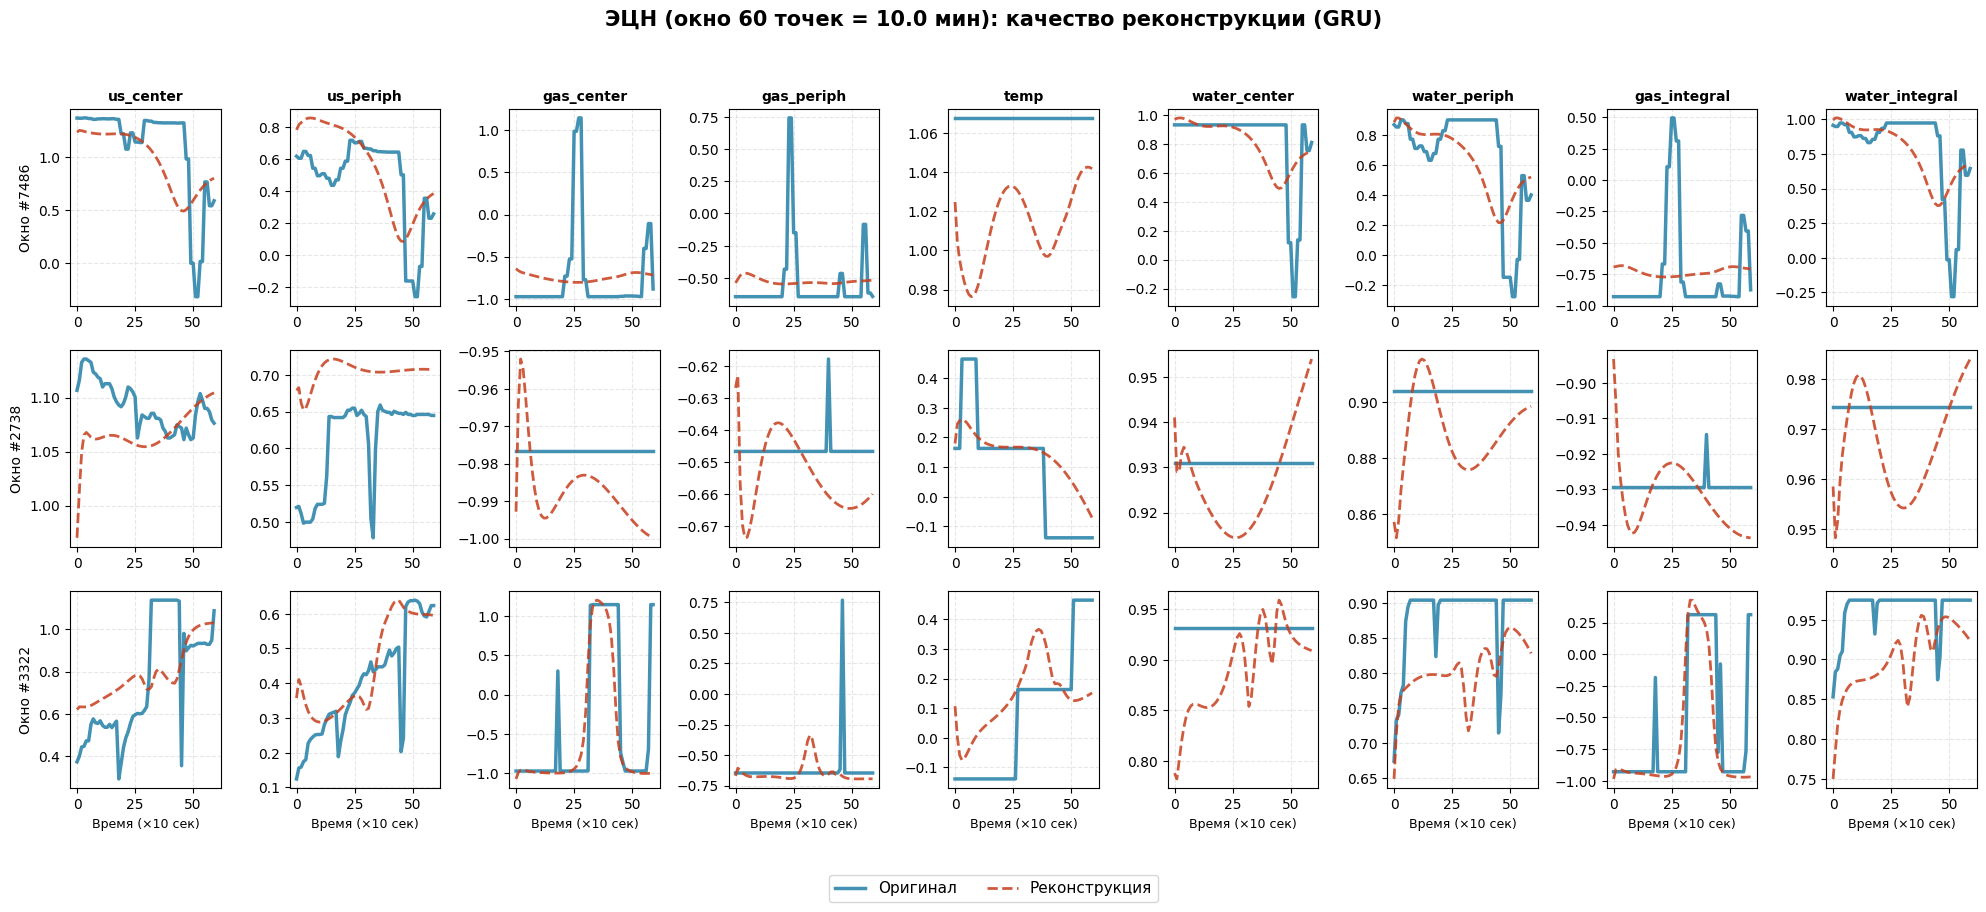

In [115]:
print("\nВизуализация реконструкции для ЭЦН:")
plot_reconstruction(ecn_best_model, X_ecn_val, WINDOW_SIZES["ecn"], "ЭЦН", COLORS["primary"])

In [111]:
print("\nВизуализация реконструкции для ШГН:")
plot_reconstruction(shgn_best_model, X_shgn_val, WINDOW_SIZES["shgn"], "ШГН", COLORS["secondary"])


Визуализация реконструкции для ШГН:


NameError: name 'shgn_best_model' is not defined

# ==== 7. СОХРАНЕНИЕ ЛУЧШИХ МОДЕЛЕЙ ====

In [ ]:
def save_model(model, scaler, prefix, best_arch, latent_dim, metrics, window_size):
    model_dir = MODELS_DIR / prefix
    model_dir.mkdir(parents=True, exist_ok=True)

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "architecture": best_arch,
            "latent_dim": latent_dim,
            "metrics": {
                "val_loss": metrics["val_loss"],
                "val_mae": metrics["val_mae"],
                "val_r2": metrics["val_r2"],
                "test_loss": metrics["test_loss"],
                "test_mae": metrics["test_mae"],
                "test_r2": metrics["test_r2"],
            },
            "window_size": window_size,
            "feature_columns": FEATURE_COLUMNS,
            "trained_at": str(datetime.now()),
            "device": str(DEVICE),
        },
        model_dir / f"{prefix}_best_model.pth",
    )

    with open(model_dir / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)

    print(f"\n{prefix.upper()}: сохранена лучшая модель")
    print(f"   Архитектура: {best_arch} | Latent dim: {latent_dim}")
    print(f"   Val  → MSE={metrics['val_loss']:.6f} | MAE={metrics['val_mae']:.4f} | R²={metrics['val_r2']:.4f}")
    print(f"   Test → MSE={metrics['test_loss']:.6f} | MAE={metrics['test_mae']:.4f} | R²={metrics['test_r2']:.4f}")
    print(f"   Путь: {model_dir.absolute()}")


save_model(
    ecn_best_model,
    scaler_ecn,
    "ecn",
    ecn_best_arch,
    ecn_results[ecn_best_arch]["best"]["latent_dim"],
    ecn_results[ecn_best_arch]["best"],
    WINDOW_SIZES["ecn"],
)

save_model(
    shgn_best_model,
    scaler_shgn,
    "shgn",
    shgn_best_arch,
    shgn_results[shgn_best_arch]["best"]["latent_dim"],
    shgn_results[shgn_best_arch]["best"],
    WINDOW_SIZES["shgn"],
)